In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

print("All libraries imported ✅")

All libraries imported ✅


In [4]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)


In [5]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [8]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f"Columns with missing values: {len(missing)}")
print(missing)

Columns with missing values: 19
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [9]:
# Group 1: Missing means "No feature" — fill text columns with "None", number columns with 0
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
             'BsmtFinType2', 'MasVnrType']

for col in none_cols:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')

# Number columns where missing = 0
zero_cols = ['GarageYrBlt', 'MasVnrArea']

for col in zero_cols:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

# Group 2: Fill with median or mode
train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].median())
test['LotFrontage'] = test['LotFrontage'].fillna(train['LotFrontage'].median())

train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])
test['Electrical'] = test['Electrical'].fillna(train['Electrical'].mode()[0])

print("Missing values after cleaning:", train.isnull().sum().sum())

Missing values after cleaning: 0


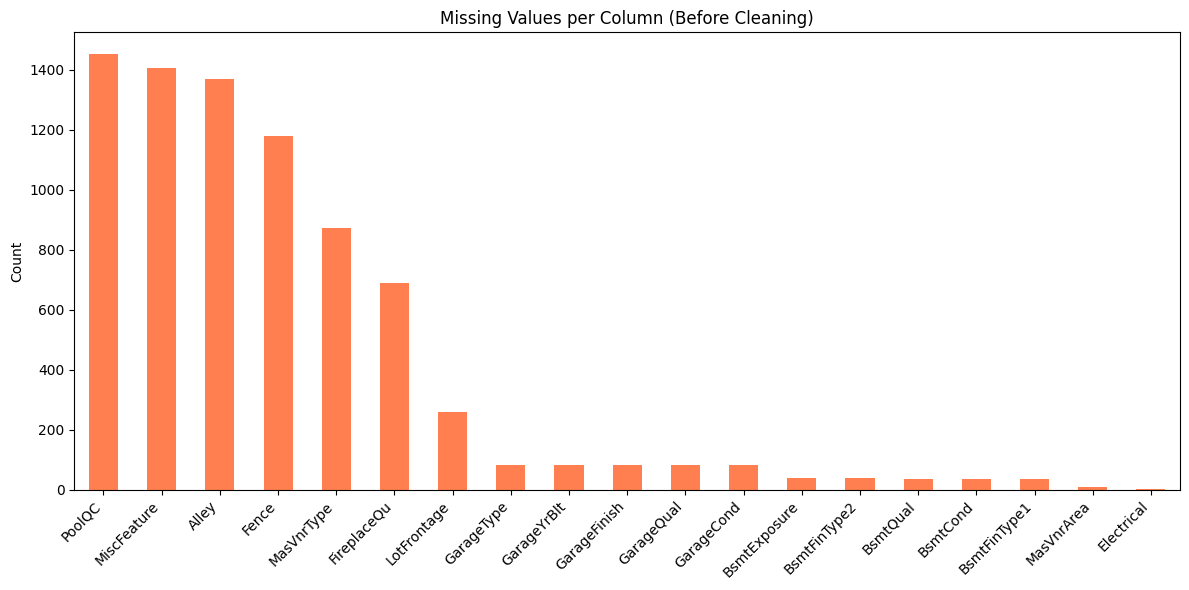

In [10]:
plt.figure(figsize=(12, 6))
missing.plot(kind='bar', color='coral')
plt.title('Missing Values per Column (Before Cleaning)')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

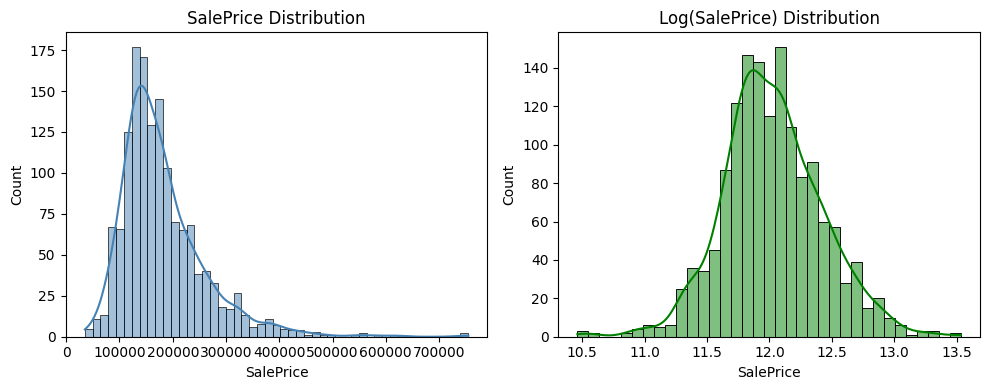

Skewness: 1.88


In [11]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(train['SalePrice'], kde=True, color='steelblue')
plt.title('SalePrice Distribution')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train['SalePrice']), kde=True, color='green')
plt.title('Log(SalePrice) Distribution')

plt.tight_layout()
plt.show()

print("Skewness:", round(train['SalePrice'].skew(), 2))

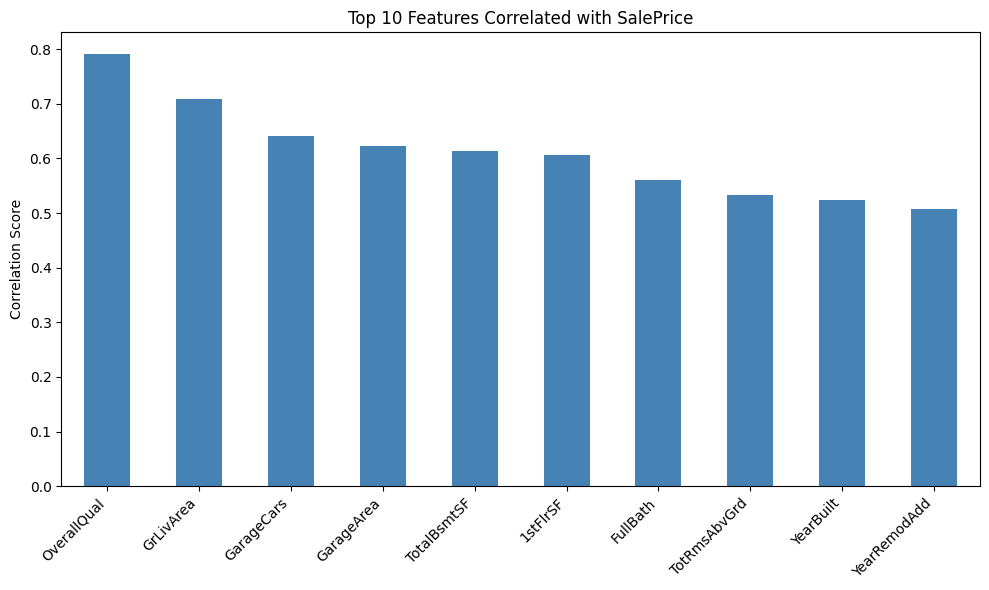

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [12]:
corr = train.select_dtypes(include='number').corr()
top_corr = corr['SalePrice'].sort_values(ascending=False).head(11)

plt.figure(figsize=(10, 6))
top_corr.drop('SalePrice').plot(kind='bar', color='steelblue')
plt.title('Top 10 Features Correlated with SalePrice')
plt.ylabel('Correlation Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(top_corr)

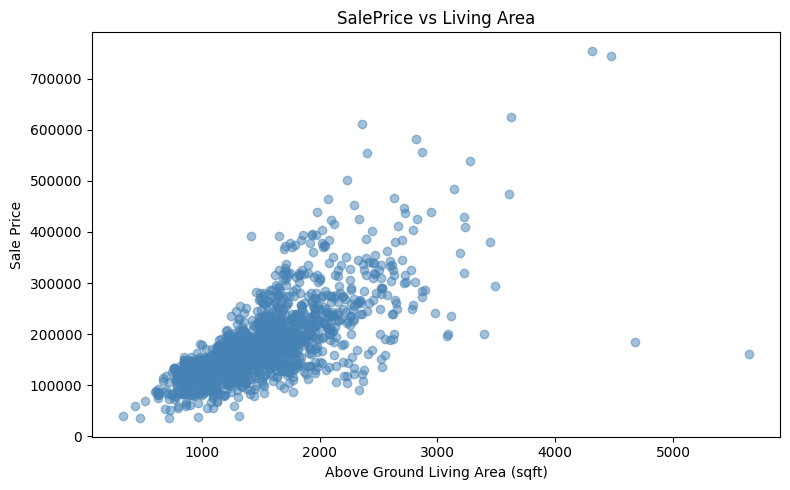

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5, color='steelblue')
plt.title('SalePrice vs Living Area')
plt.xlabel('Above Ground Living Area (sqft)')
plt.ylabel('Sale Price')
plt.tight_layout()
plt.show()

In [14]:
# Remove the 2 outlier houses
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]

print("Train shape after removing outliers:", train.shape)

Train shape after removing outliers: (1458, 81)


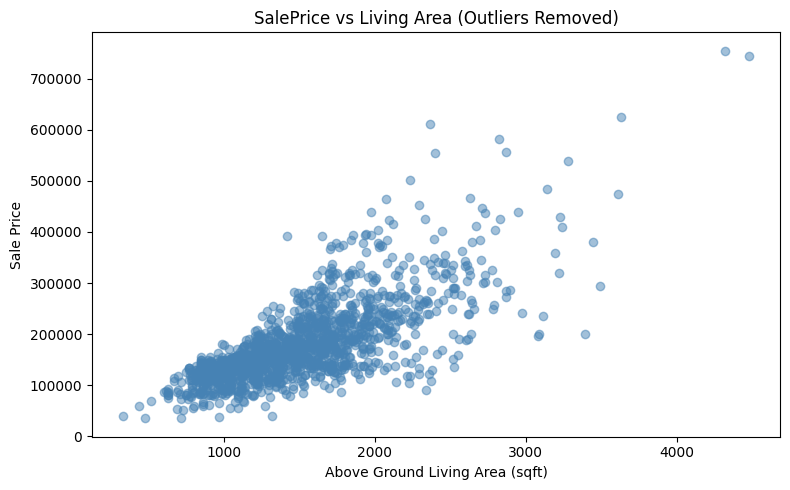

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5, color='steelblue')
plt.title('SalePrice vs Living Area (Outliers Removed)')
plt.xlabel('Above Ground Living Area (sqft)')
plt.ylabel('Sale Price')
plt.tight_layout()
plt.show()

In [17]:
# Log transform the target variable
train['SalePrice'] = np.log1p(train['SalePrice'])

print("SalePrice after log transform:")
print(train['SalePrice'].describe())

SalePrice after log transform:
count    1458.000000
mean        2.566325
std         0.030680
min         2.438886
25%         2.547468
50%         2.565066
75%         2.585787
max         2.676523
Name: SalePrice, dtype: float64


In [23]:
# Create new features from existing ones
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']

train['TotalBathrooms'] = (train['FullBath'] + train['HalfBath'] * 0.5 +
                           train['BsmtFullBath'] + train['BsmtHalfBath'] * 0.5)
test['TotalBathrooms'] = (test['FullBath'] + test['HalfBath'] * 0.5 +
                          test['BsmtFullBath'] + test['BsmtHalfBath'] * 0.5)

train['HouseAge'] = train['YrSold'] - train['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

train['IsRemodeled'] = (train['YearRemodAdd'] != train['YearBuilt']).astype(int)
test['IsRemodeled'] = (test['YearRemodAdd'] != test['YearBuilt']).astype(int)

print("New features added ✅")
print(train[['TotalSF', 'TotalBathrooms', 'HouseAge', 'IsRemodeled']].head())

New features added ✅
   TotalSF  TotalBathrooms  HouseAge  IsRemodeled
0     2566             3.5         5            0
1     2524             2.5        31            0
2     2706             3.5         7            1
3     2473             2.0        91            1
4     3343             3.5         8            0


In [24]:
# Convert text columns to numbers
from sklearn.preprocessing import LabelEncoder

cat_cols = train.select_dtypes(include='object').columns

le = LabelEncoder()
for col in cat_cols:
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.fit_transform(test[col].astype(str))

print("Categorical columns encoded ✅")
print(f"Total columns now: {train.shape[1]}")

Categorical columns encoded ✅
Total columns now: 85


In [25]:
# Separate features and target
X = train.drop(['SalePrice', 'Id'], axis=1)
y = train['SalePrice']
X_test = test.drop(['Id'], axis=1)

# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1166, 83)
X_val shape: (292, 83)
y_train shape: (1166,)


In [21]:
# Reload fresh data
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

# Clean missing values
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
             'BsmtFinType2', 'MasVnrType']
for col in none_cols:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')

zero_cols = ['GarageYrBlt', 'MasVnrArea']
for col in zero_cols:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].median())
test['LotFrontage'] = test['LotFrontage'].fillna(train['LotFrontage'].median())
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])
test['Electrical'] = test['Electrical'].fillna(train['Electrical'].mode()[0])

# Remove outliers
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]

# Log transform ONCE
train['SalePrice'] = np.log1p(train['SalePrice'])

print("SalePrice after log transform:")
print(train['SalePrice'].describe())

SalePrice after log transform:
count    1458.000000
mean       12.024015
std         0.399713
min        10.460271
25%        11.774720
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice, dtype: float64


In [26]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_val)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_pred))
print(f"Linear Regression RMSE: {lr_rmse:.4f}")

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))
print(f"Random Forest RMSE:     {rf_rmse:.4f}")

# Model 3: XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, 
                               max_depth=5, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train, 
              eval_set=[(X_val, y_val)], 
              verbose=False)
xgb_pred = xgb_model.predict(X_val)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_pred))
print(f"XGBoost RMSE:           {xgb_rmse:.4f}")

Linear Regression RMSE: 0.1265
Random Forest RMSE:     0.1454
XGBoost RMSE:           0.1286


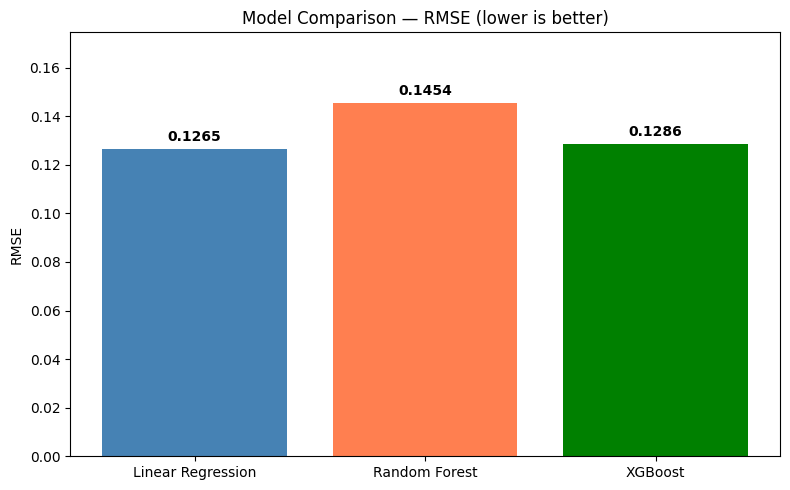

In [27]:
models = ['Linear Regression', 'Random Forest', 'XGBoost']
rmses = [lr_rmse, rf_rmse, xgb_rmse]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, rmses, color=['steelblue', 'coral', 'green'])
plt.title('Model Comparison — RMSE (lower is better)')
plt.ylabel('RMSE')
plt.ylim(0, max(rmses) * 1.2)

for bar, rmse in zip(bars, rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{rmse:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

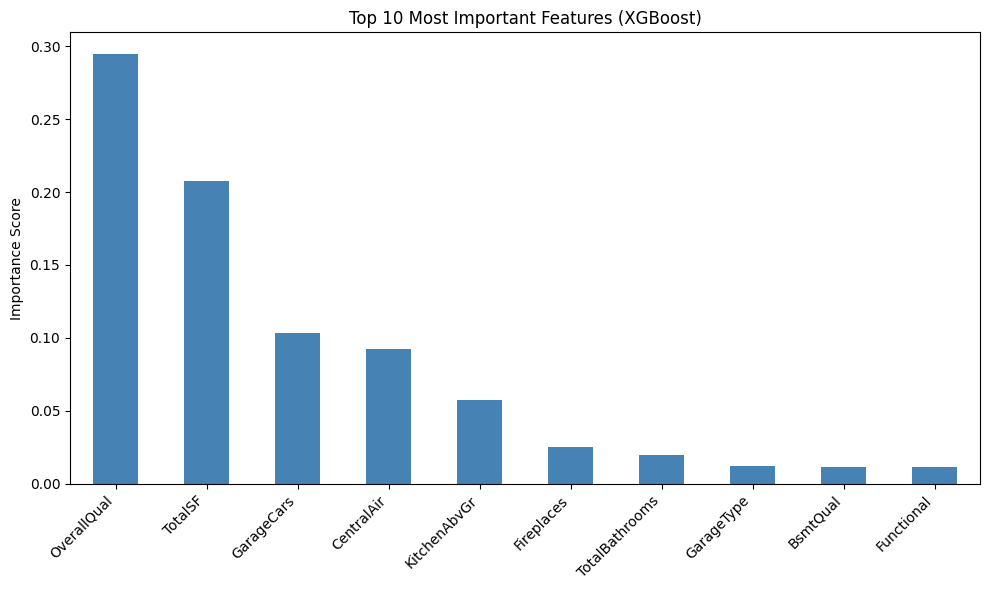

OverallQual       0.294707
TotalSF           0.207446
GarageCars        0.103602
CentralAir        0.092440
KitchenAbvGr      0.057344
Fireplaces        0.025140
TotalBathrooms    0.020049
GarageType        0.012118
BsmtQual          0.011699
Functional        0.011619
dtype: float32


In [28]:
# Which features mattered most?
feat_imp = pd.Series(xgb_model.feature_importances_, 
                     index=X_train.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Top 10 Most Important Features (XGBoost)')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(feat_imp)

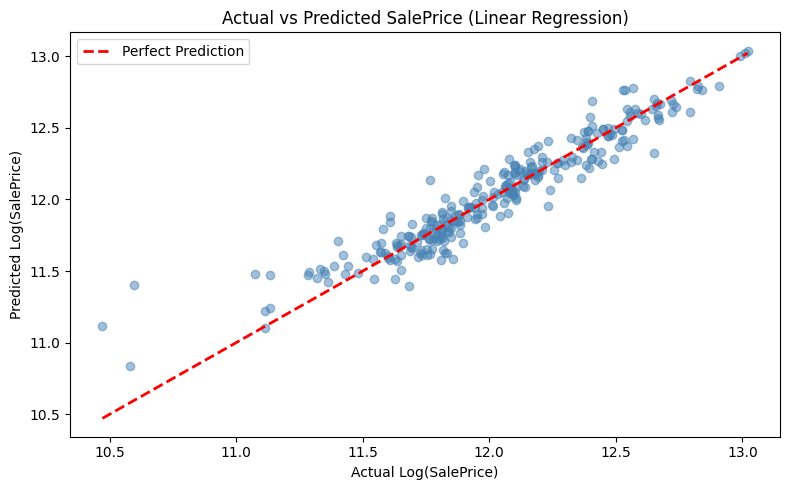

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(y_val, lr_pred, alpha=0.5, color='steelblue')
plt.plot([y_val.min(), y_val.max()], 
         [y_val.min(), y_val.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted SalePrice (Linear Regression)')
plt.xlabel('Actual Log(SalePrice)')
plt.ylabel('Predicted Log(SalePrice)')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# Check where NaNs are in test set
print("NaNs in X_test:", X_test.isnull().sum().sum())
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

NaNs in X_test: 13
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
BsmtFullBath      2
BsmtHalfBath      2
GarageCars        1
GarageArea        1
TotalSF           1
TotalBathrooms    2
dtype: int64


In [32]:
# Fill remaining numeric NaNs with median
for col in X_test.columns:
    if X_test[col].isnull().sum() > 0:
        if X_test[col].dtype in ['float64', 'int64']:
            X_test[col] = X_test[col].fillna(X_test[col].median())
        else:
            X_test[col] = X_test[col].fillna(X_test[col].mode()[0])

print("NaNs after fix:", X_test.isnull().sum().sum())

NaNs after fix: 0


In [33]:
# Use Linear Regression (best model) to predict test set
final_pred = lr.predict(X_test)

# Convert back from log to actual prices
final_pred = np.expm1(final_pred)

# Create submission file
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': final_pred
})

submission.to_csv('submission.csv', index=False)
print("Submission file created ✅")
print(submission.head(10))

Submission file created ✅
     Id      SalePrice
0  1461  106691.826906
1  1462  135147.051026
2  1463  151788.988125
3  1464  168133.773947
4  1465  160368.394890
5  1466  150338.351945
6  1467  157333.228852
7  1468  143470.991650
8  1469  166414.503924
9  1470  103169.268899


In [34]:
print("=" * 50)
print("   HOUSE PRICE PREDICTION — PROJECT SUMMARY")
print("=" * 50)
print(f"\n Dataset: 1458 houses, 83 features")
print(f"\n Models Trained:")
print(f"   Linear Regression RMSE : {lr_rmse:.4f} 🥇")
print(f"   XGBoost RMSE           : {xgb_rmse:.4f} 🥈")
print(f"   Random Forest RMSE     : {rf_rmse:.4f} 🥉")
print(f"\n Best Model : Linear Regression")
print(f" Key Features: OverallQual, TotalSF, GarageCars")
print(f"\n Submission file saved as submission.csv ✅")
print("=" * 50)

   HOUSE PRICE PREDICTION — PROJECT SUMMARY

 Dataset: 1458 houses, 83 features

 Models Trained:
   Linear Regression RMSE : 0.1265 🥇
   XGBoost RMSE           : 0.1286 🥈
   Random Forest RMSE     : 0.1454 🥉

 Best Model : Linear Regression
 Key Features: OverallQual, TotalSF, GarageCars

 Submission file saved as submission.csv ✅
